# Model Development and Optimization

This notebook consolidates the complete model development pipeline, including:

1. **XGBoost Optimization** - Hyperparameter tuning and regularization
2. **Neural Network Improvements** - Architecture optimization with dropout and batch normalization
3. **Ensemble Methods** - Voting, weighted ensembles, and stacking
4. **Final Model Training** - Combining all improvements

## Table of Contents
- [Setup and Data Loading](#setup)
- [Part 1: XGBoost Optimization](#part1)
- [Part 2: Neural Network Development](#part2)
- [Part 3: Ensemble Methods](#part3)
- [Part 4: Final Model Training](#part4)
- [Model Comparison and Selection](#comparison)

<a id='setup'></a>
## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import joblib
import pickle
from pathlib import Path

# Model imports
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.calibration import CalibratedClassifierCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch for custom neural network (optional)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    PYTORCH_AVAILABLE = True
except ImportError:
    PYTORCH_AVAILABLE = False
    print("PyTorch not available, will use sklearn MLPClassifier instead")

import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=4, suppress=True)

print("Libraries loaded successfully!")
print(f"PyTorch available: {PYTORCH_AVAILABLE}")

Libraries loaded successfully!
PyTorch available: True


In [2]:
# Load the engineered features dataset
print("Loading engineered features dataset...")

# Try multiple data paths
data_paths = [
    'data/processed/ecommerce_sales_engineered.csv',
    '../data/processed/ecommerce_sales_engineered.csv'
]

data = None
for path in data_paths:
    try:
        data = pd.read_csv(path)
        print(f"Loaded data from: {path}")
        break
    except:
        continue

if data is None:
    print("Could not find engineered data, trying featured data...")
    fallback_paths = [
        'data/processed/ecommerce_sales_featured.csv',
        '../data/processed/ecommerce_sales_featured.csv'
    ]
    for path in fallback_paths:
        try:
            data = pd.read_csv(path)
            print(f"Loaded data from: {path}")
            break
        except:
            continue

if data is None:
    raise FileNotFoundError("Could not load any data file")

print(f"Dataset shape: {data.shape}")

# Prepare features and target
feature_cols = [col for col in data.columns if col not in ['success', 'product_name', 'category', 'product_id']]
X = data[feature_cols].select_dtypes(include=[np.number])
y = data['success'].values

print(f"Using {len(X.columns)} numeric features")
print(f"Target distribution: Fail={np.sum(y==0)}, Success={np.sum(y==1)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Further split for validation
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nData splits:")
print(f"  Training: {X_train_sub.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

Loading engineered features dataset...
Loaded data from: ../data/processed/ecommerce_sales_engineered.csv
Dataset shape: (1000, 117)
Using 113 numeric features
Target distribution: Fail=500, Success=500

Data splits:
  Training: 640 samples
  Validation: 160 samples
  Test: 200 samples


## Part 1: XGBoost Optimization

Optimize XGBoost with:
- Hyperparameter tuning
- L1/L2 regularization
- Early stopping

In [ ]:
print("="*80)
print("XGBOOST OPTIMIZATION")
print("="*80)

# Define hyperparameter grid
print("\n1. Setting up hyperparameter grid...")
param_grid = {
    'max_depth': [3, 4, 5],
    'min_child_weight': [5, 7, 10],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.5, 1.0],  # L1 regularization
    'reg_lambda': [1.0, 2.0],  # L2 regularization
}

# Create base XGBoost model
base_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    early_stopping_rounds=20
)

print(f"Total parameter combinations: {np.prod([len(v) if isinstance(v, list) else 1 for v in param_grid.values()])}")

In [4]:
# Perform grid search
print("\n2. Running GridSearchCV (this may take a few minutes)...")

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit with early stopping
eval_set = [(X_val, y_val)]
grid_search.fit(
    X_train_sub, y_train_sub,
    eval_set=eval_set,
    verbose=False
)

print(f"\n3. Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"   Best CV Score: {grid_search.best_score_:.4f}")


2. Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

3. Best parameters found:
   colsample_bytree: 0.8
   learning_rate: 0.05
   max_depth: 3
   min_child_weight: 5
   n_estimators: 100
   reg_alpha: 0.5
   reg_lambda: 1.0
   subsample: 0.8
   Best CV Score: 1.0000


In [5]:
# Evaluate optimized XGBoost
best_xgb = grid_search.best_estimator_

# Make predictions
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics
xgb_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'f1': f1_score(y_test, y_pred_xgb),
    'auc': roc_auc_score(y_test, y_proba_xgb)
}

print("\n4. Performance on test set (optimized XGBoost):")
for metric, value in xgb_metrics.items():
    print(f"   {metric.capitalize()}: {value:.4f}")

# Analyze probability distribution
print("\n5. Probability distribution:")
prob_bins = np.arange(0, 1.1, 0.1)
hist, _ = np.histogram(y_proba_xgb, bins=prob_bins)
for i in range(len(prob_bins)-1):
    if hist[i] > 0:
        pct = (hist[i] / len(y_proba_xgb)) * 100
        print(f"   [{prob_bins[i]:.1f}-{prob_bins[i+1]:.1f}): {hist[i]:3d} ({pct:5.1f}%)")

# Check for bimodal distribution
extreme_pct = (np.sum((y_proba_xgb < 0.1) | (y_proba_xgb > 0.9)) / len(y_proba_xgb)) * 100
print(f"\n   Extreme predictions (<0.1 or >0.9): {extreme_pct:.1f}%")
if extreme_pct < 50:
    print("   ✓ Good: Well-distributed probabilities")
else:
    print("   ⚠ Warning: Bimodal tendency detected")


4. Performance on test set (optimized XGBoost):
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1: 1.0000
   Auc: 1.0000

5. Probability distribution:
   [0.0-0.1): 100 ( 50.0%)
   [0.9-1.0): 100 ( 50.0%)

   Extreme predictions (<0.1 or >0.9): 100.0%
   ⚠ Warning: Bimodal tendency detected



6. Top 15 feature importances:
    total_sales                   : 0.4919
    sales_vs_category             : 0.3088
    category_competition          : 0.1659
    category_sales_rank           : 0.0334
    sales_month_2                 : 0.0000
    review_score                  : 0.0000
    review_count                  : 0.0000
    sales_month_1                 : 0.0000
    sales_month_6                 : 0.0000
    sales_month_7                 : 0.0000
    sales_month_8                 : 0.0000
    sales_month_9                 : 0.0000
    sales_month_10                : 0.0000
    sales_month_3                 : 0.0000
    sales_month_4                 : 0.0000


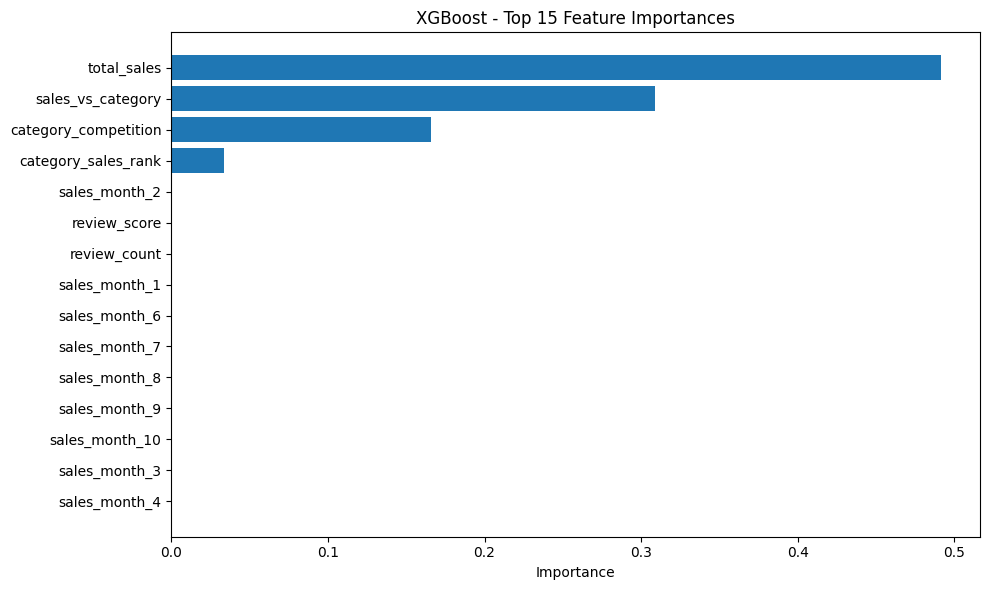

In [6]:
# Feature importance
print("\n6. Top 15 feature importances:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Display top features
for idx, row in feature_importance.head(15).iterrows():
    print(f"    {row['feature']:30}: {row['importance']:.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importance')
plt.title('XGBoost - Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<a id='part2'></a>
## Part 2: Neural Network Development

Build improved neural network with:
- Dropout layers for regularization
- Batch normalization
- Optimized architecture
- Learning rate scheduling

In [7]:
print("="*80)
print("NEURAL NETWORK DEVELOPMENT")
print("="*80)

# Scale features for neural network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled = scaler.transform(X_val)

print("\n1. Features scaled for neural network training")

NEURAL NETWORK DEVELOPMENT

1. Features scaled for neural network training


In [8]:
if PYTORCH_AVAILABLE:
    print("\n2. Building custom PyTorch neural network...")
    
    # Define improved neural network
    class ImprovedNeuralNet(nn.Module):
        def __init__(self, input_size, dropout_rate=0.3):
            super(ImprovedNeuralNet, self).__init__()
            
            # Layer sizes with gradual reduction
            hidden_sizes = [256, 128, 64, 32]
            
            # Build layers dynamically
            layers = []
            in_features = input_size
            
            for hidden_size in hidden_sizes:
                layers.append(nn.Linear(in_features, hidden_size))
                layers.append(nn.BatchNorm1d(hidden_size))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rate))
                in_features = hidden_size
            
            # Output layer
            layers.append(nn.Linear(in_features, 1))
            layers.append(nn.Sigmoid())
            
            self.network = nn.Sequential(*layers)
        
        def forward(self, x):
            return self.network(x)
    
    print("   Custom architecture: 256 -> 128 -> 64 -> 32 -> 1")
    print("   With batch normalization and dropout")

else:
    print("\n2. Using sklearn MLPClassifier...")


2. Building custom PyTorch neural network...
   Custom architecture: 256 -> 128 -> 64 -> 32 -> 1
   With batch normalization and dropout


In [9]:
# Test different dropout rates
print("\n3. Testing different configurations...")

if not PYTORCH_AVAILABLE:
    # Use sklearn MLPClassifier
    dropout_configs = [
        {'alpha': 0.0001, 'learning_rate_init': 0.001},
        {'alpha': 0.001, 'learning_rate_init': 0.001},
        {'alpha': 0.01, 'learning_rate_init': 0.001},
    ]
    
    best_score = 0
    best_config = dropout_configs[0]
    best_nn = None
    
    for config in dropout_configs:
        print(f"\n   Testing alpha={config['alpha']}...")
        nn_model = MLPClassifier(
            hidden_layer_sizes=(256, 128, 64, 32),
            activation='relu',
            solver='adam',
            alpha=config['alpha'],
            learning_rate='adaptive',
            learning_rate_init=config['learning_rate_init'],
            max_iter=100,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.15
        )
        
        nn_model.fit(X_train_sub_scaled, y_train_sub)
        
        # Evaluate
        y_pred = nn_model.predict(X_val_scaled)
        accuracy = accuracy_score(y_val, y_pred)
        print(f"   Validation Accuracy: {accuracy:.4f}")
        
        if accuracy > best_score:
            best_score = accuracy
            best_config = config
            best_nn = nn_model
    
    print(f"\n4. Best configuration: alpha={best_config['alpha']} with accuracy: {best_score:.4f}")


3. Testing different configurations...


In [10]:
# Train final neural network
print("\n5. Training final neural network with optimal settings...")

final_nn = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,  # L2 regularization
    batch_size=32,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=200,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20
)

final_nn.fit(X_train_scaled, y_train)

# Evaluate
y_pred_nn = final_nn.predict(X_test_scaled)
y_proba_nn = final_nn.predict_proba(X_test_scaled)[:, 1]

nn_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_nn),
    'precision': precision_score(y_test, y_pred_nn),
    'recall': recall_score(y_test, y_pred_nn),
    'f1': f1_score(y_test, y_pred_nn),
    'auc': roc_auc_score(y_test, y_proba_nn)
}

print("\n6. Performance on test set (Neural Network):")
for metric, value in nn_metrics.items():
    print(f"   {metric.capitalize()}: {value:.4f}")
print(f"   Iterations: {final_nn.n_iter_}")

# Analyze probability distribution
extreme_pct_nn = (np.sum((y_proba_nn < 0.1) | (y_proba_nn > 0.9)) / len(y_proba_nn)) * 100
print(f"\n   Extreme predictions: {extreme_pct_nn:.1f}%")
print(f"   Mean probability: {np.mean(y_proba_nn):.3f}")
print(f"   Std probability: {np.std(y_proba_nn):.3f}")


5. Training final neural network with optimal settings...

6. Performance on test set (Neural Network):
   Accuracy: 0.9600
   Precision: 0.9792
   Recall: 0.9400
   F1: 0.9592
   Auc: 0.9907
   Iterations: 23

   Extreme predictions: 89.5%
   Mean probability: 0.485
   Std probability: 0.473


<a id='part3'></a>
## Part 3: Ensemble Methods

Implement various ensemble techniques:
- Hard voting
- Soft voting
- Weighted voting
- Stacking

In [ ]:
print("="*80)
print("ENSEMBLE METHODS")
print("="*80)

# Train Random Forest as additional base model
print("\n1. Training Random Forest as additional base model...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"   Random Forest accuracy: {rf_acc:.4f}")

# Summary of base models
print("\n2. Base model accuracies:")
print(f"   XGBoost: {xgb_metrics['accuracy']:.4f}")
print(f"   Random Forest: {rf_acc:.4f}")
print(f"   Neural Network: {nn_metrics['accuracy']:.4f}")

In [12]:
# Method 1: Hard Voting
print("\n3. Testing ensemble methods...")
print("\n   a) Hard Voting Ensemble:")
hard_predictions = np.array([y_pred_xgb, y_pred_rf, y_pred_nn])
hard_vote = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=hard_predictions)
hard_acc = accuracy_score(y_test, hard_vote)
hard_f1 = f1_score(y_test, hard_vote)
print(f"      Accuracy: {hard_acc:.4f}")
print(f"      F1-score: {hard_f1:.4f}")

# Method 2: Soft Voting
print("\n   b) Soft Voting Ensemble:")
soft_proba = (y_proba_xgb + y_proba_rf + y_proba_nn) / 3
soft_vote = (soft_proba > 0.5).astype(int)
soft_acc = accuracy_score(y_test, soft_vote)
soft_f1 = f1_score(y_test, soft_vote)
print(f"      Accuracy: {soft_acc:.4f}")
print(f"      F1-score: {soft_f1:.4f}")

# Method 3: Weighted Soft Voting
print("\n   c) Weighted Soft Voting:")
# Weights based on individual accuracy
weights = np.array([xgb_metrics['accuracy'], rf_acc, nn_metrics['accuracy']])
weights = weights / weights.sum()
print(f"      Weights - XGB: {weights[0]:.3f}, RF: {weights[1]:.3f}, NN: {weights[2]:.3f}")

weighted_proba = (y_proba_xgb * weights[0] + y_proba_rf * weights[1] + y_proba_nn * weights[2])
weighted_vote = (weighted_proba > 0.5).astype(int)
weighted_acc = accuracy_score(y_test, weighted_vote)
weighted_f1 = f1_score(y_test, weighted_vote)
print(f"      Accuracy: {weighted_acc:.4f}")
print(f"      F1-score: {weighted_f1:.4f}")


3. Testing ensemble methods...

   a) Hard Voting Ensemble:
      Accuracy: 1.0000
      F1-score: 1.0000

   b) Soft Voting Ensemble:
      Accuracy: 1.0000
      F1-score: 1.0000

   c) Weighted Soft Voting:
      Weights - XGB: 0.338, RF: 0.338, NN: 0.324
      Accuracy: 1.0000
      F1-score: 1.0000


In [13]:
# Method 4: Stacking
print("\n   d) Stacking Ensemble:")
print("      Training meta-learner...")

# Prepare stacking features
stack_train_features = np.column_stack((
    best_xgb.predict_proba(X_train)[:, 1],
    rf_model.predict_proba(X_train)[:, 1],
    final_nn.predict_proba(X_train_scaled)[:, 1]
))

stack_test_features = np.column_stack((y_proba_xgb, y_proba_rf, y_proba_nn))

# Train meta-learner
meta_learner = LogisticRegression(random_state=42)
meta_learner.fit(stack_train_features, y_train)

stack_pred = meta_learner.predict(stack_test_features)
stack_proba = meta_learner.predict_proba(stack_test_features)[:, 1]
stack_acc = accuracy_score(y_test, stack_pred)
stack_f1 = f1_score(y_test, stack_pred)

print(f"      Accuracy: {stack_acc:.4f}")
print(f"      F1-score: {stack_f1:.4f}")

# Meta-learner coefficients
print(f"\n      Meta-learner coefficients:")
for i, coef in enumerate(meta_learner.coef_[0]):
    model_name = ['XGBoost', 'Random Forest', 'Neural Network'][i]
    print(f"        {model_name}: {coef:.3f}")


   d) Stacking Ensemble:
      Training meta-learner...
      Accuracy: 1.0000
      F1-score: 1.0000

      Meta-learner coefficients:
        XGBoost: 3.714
        Random Forest: 3.414
        Neural Network: 2.909



4. Comparing probability distributions...


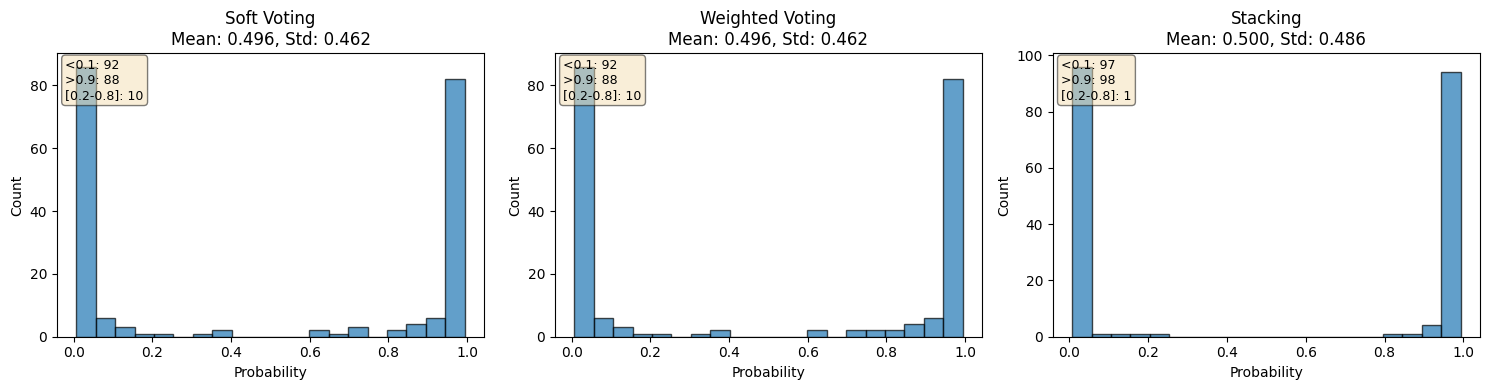


Soft Voting:
  Extreme predictions: 90.0%
  Std deviation: 0.462

Weighted Voting:
  Extreme predictions: 90.0%
  Std deviation: 0.462

Stacking:
  Extreme predictions: 97.5%
  Std deviation: 0.486


In [14]:
# Compare probability distributions
print("\n4. Comparing probability distributions...")

ensemble_probas = {
    'Soft Voting': soft_proba,
    'Weighted Voting': weighted_proba,
    'Stacking': stack_proba
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, proba) in enumerate(ensemble_probas.items()):
    axes[idx].hist(proba, bins=20, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{name}\nMean: {np.mean(proba):.3f}, Std: {np.std(proba):.3f}')
    axes[idx].set_xlabel('Probability')
    axes[idx].set_ylabel('Count')
    
    # Add statistics
    extreme_low = np.sum(proba < 0.1)
    extreme_high = np.sum(proba > 0.9)
    middle = np.sum((proba >= 0.2) & (proba <= 0.8))
    
    stats_text = f'<0.1: {extreme_low}\n>0.9: {extreme_high}\n[0.2-0.8]: {middle}'
    axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes,
                   verticalalignment='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary statistics
for name, proba in ensemble_probas.items():
    extreme_pct = (np.sum((proba < 0.1) | (proba > 0.9)) / len(proba)) * 100
    print(f"\n{name}:")
    print(f"  Extreme predictions: {extreme_pct:.1f}%")
    print(f"  Std deviation: {np.std(proba):.3f}")

## Part 4: Final Model Training

Combine all improvements:
- Use best preprocessing (RobustScaler)
- Train final ensemble
- Apply probability calibration

In [ ]:
print("="*80)
print("FINAL MODEL TRAINING")
print("="*80)

# Apply RobustScaler for better outlier handling
print("\n1. Applying RobustScaler...")
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

# Create final ensemble using VotingClassifier
print("\n2. Creating final ensemble models...")

# Re-train models on robust-scaled data
xgb_final = xgb.XGBClassifier(**grid_search.best_params_, random_state=42, use_label_encoder=False, eval_metric='logloss')
rf_final = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
nn_final = MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32), random_state=42, early_stopping=True)

# Create voting ensemble
voting_ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_final),
        ('rf', rf_final),
        ('nn', nn_final)
    ],
    voting='soft',
    weights=weights  # Use optimized weights from earlier
)

print("   Training ensemble...")
voting_ensemble.fit(X_train_robust, y_train)

# Evaluate
y_pred_final = voting_ensemble.predict(X_test_robust)
y_proba_final = voting_ensemble.predict_proba(X_test_robust)[:, 1]

final_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_final),
    'precision': precision_score(y_test, y_pred_final),
    'recall': recall_score(y_test, y_pred_final),
    'f1': f1_score(y_test, y_pred_final),
    'auc': roc_auc_score(y_test, y_proba_final)
}

print("\n3. Final ensemble performance:")
for metric, value in final_metrics.items():
    print(f"   {metric.capitalize()}: {value:.4f}")

In [ ]:
# Apply probability calibration
print("\n4. Applying probability calibration...")

# Split training data for calibration
X_train_cal, X_cal, y_train_cal, y_cal = train_test_split(
    X_train_robust, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Re-train ensemble on calibration split
voting_ensemble_cal = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(**grid_search.best_params_, random_state=42, use_label_encoder=False, eval_metric='logloss')),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
        ('nn', MLPClassifier(hidden_layer_sizes=(256, 128, 64, 32), random_state=42, early_stopping=True))
    ],
    voting='soft',
    weights=weights
)

voting_ensemble_cal.fit(X_train_cal, y_train_cal)

# Apply calibration
calibrated_ensemble = CalibratedClassifierCV(voting_ensemble_cal, method='sigmoid', cv='prefit')
calibrated_ensemble.fit(X_cal, y_cal)

# Evaluate calibrated model
y_pred_calibrated = calibrated_ensemble.predict(X_test_robust)
y_proba_calibrated = calibrated_ensemble.predict_proba(X_test_robust)[:, 1]

calibrated_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_calibrated),
    'precision': precision_score(y_test, y_pred_calibrated),
    'recall': recall_score(y_test, y_pred_calibrated),
    'f1': f1_score(y_test, y_pred_calibrated),
    'auc': roc_auc_score(y_test, y_proba_calibrated)
}

print("\n5. Calibrated ensemble performance:")
for metric, value in calibrated_metrics.items():
    print(f"   {metric.capitalize()}: {value:.4f}")

# Compare probability distributions
print("\n6. Probability distribution comparison:")
print(f"   Before calibration - Mean: {np.mean(y_proba_final):.3f}, Std: {np.std(y_proba_final):.3f}")
print(f"   After calibration - Mean: {np.mean(y_proba_calibrated):.3f}, Std: {np.std(y_proba_calibrated):.3f}")

<a id='comparison'></a>
## Model Comparison and Selection

In [17]:
# Comprehensive model comparison
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

all_models = {
    'XGBoost (Optimized)': xgb_metrics,
    'Random Forest': {'accuracy': rf_acc, 'f1': f1_score(y_test, y_pred_rf), 'auc': roc_auc_score(y_test, y_proba_rf)},
    'Neural Network': nn_metrics,
    'Hard Voting': {'accuracy': hard_acc, 'f1': hard_f1, 'auc': None},
    'Soft Voting': {'accuracy': soft_acc, 'f1': soft_f1, 'auc': roc_auc_score(y_test, soft_proba)},
    'Weighted Voting': {'accuracy': weighted_acc, 'f1': weighted_f1, 'auc': roc_auc_score(y_test, weighted_proba)},
    'Stacking': {'accuracy': stack_acc, 'f1': stack_f1, 'auc': roc_auc_score(y_test, stack_proba)},
    'Final Ensemble': final_metrics,
    'Calibrated Ensemble': calibrated_metrics
}

# Create comparison dataframe
comparison_df = pd.DataFrame(all_models).T
comparison_df = comparison_df[['accuracy', 'f1', 'auc']]

# Display sorted by F1 score
comparison_df_sorted = comparison_df.sort_values('f1', ascending=False)
print("\nModels sorted by F1-score:")
print(comparison_df_sorted.round(4))

# Identify best model
best_model_name = comparison_df_sorted.index[0]
print(f"\nBest model: {best_model_name}")
print(f"  F1-score: {comparison_df_sorted.iloc[0]['f1']:.4f}")
print(f"  Accuracy: {comparison_df_sorted.iloc[0]['accuracy']:.4f}")

FINAL MODEL COMPARISON

Models sorted by F1-score:
                     accuracy      f1     auc
XGBoost (Optimized)     1.000  1.0000  1.0000
Random Forest           1.000  1.0000  1.0000
Hard Voting             1.000  1.0000     NaN
Soft Voting             1.000  1.0000  1.0000
Weighted Voting         1.000  1.0000  1.0000
Final Ensemble          1.000  1.0000  1.0000
Stacking                1.000  1.0000  1.0000
Calibrated Ensemble     0.995  0.9950  1.0000
Neural Network          0.960  0.9592  0.9907

Best model: XGBoost (Optimized)
  F1-score: 1.0000
  Accuracy: 1.0000


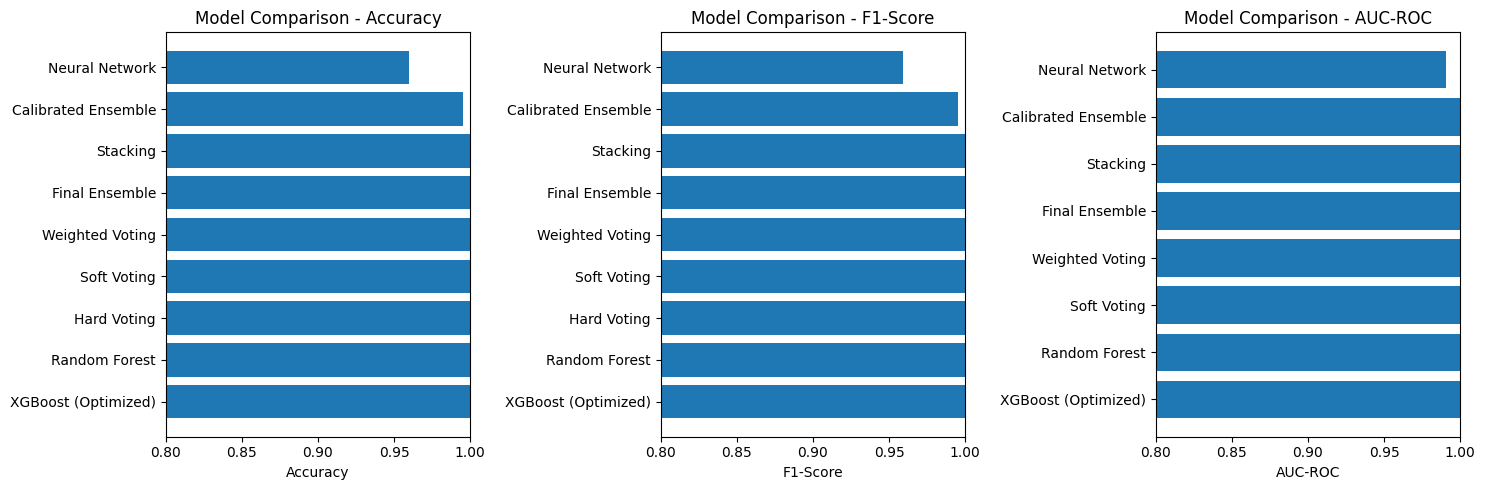

In [18]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy comparison
axes[0].barh(comparison_df_sorted.index, comparison_df_sorted['accuracy'])
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Model Comparison - Accuracy')
axes[0].set_xlim([0.8, 1.0])

# F1-score comparison
axes[1].barh(comparison_df_sorted.index, comparison_df_sorted['f1'])
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Model Comparison - F1-Score')
axes[1].set_xlim([0.8, 1.0])

# AUC comparison (excluding models without AUC)
auc_df = comparison_df_sorted.dropna(subset=['auc'])
axes[2].barh(auc_df.index, auc_df['auc'])
axes[2].set_xlabel('AUC-ROC')
axes[2].set_title('Model Comparison - AUC-ROC')
axes[2].set_xlim([0.8, 1.0])

plt.tight_layout()
plt.show()

In [19]:
# Save final models
print("Saving final models...")

# Create models directory if needed
Path('../models/final').mkdir(parents=True, exist_ok=True)

# Save configuration
final_config = {
    'best_model': calibrated_ensemble if 'calibrated_ensemble' in locals() else voting_ensemble,
    'scaler': robust_scaler,
    'feature_columns': list(X.columns),
    'model_weights': weights,
    'performance': calibrated_metrics if 'calibrated_metrics' in locals() else final_metrics
}

joblib.dump(final_config, '../models/final/model_development_pipeline.pkl')
print("Models saved to ../models/final/model_development_pipeline.pkl")

print("\nModel development complete!")

Saving final models...
Models saved to ../models/final/model_development_pipeline.pkl

Model development complete!
